In [1]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langchain.schema import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [2]:
load_dotenv()

True

In [3]:
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool 
def calculator(first_num:float , second_num:float, operation: str)->dict:
    """
     Perform a basic arithmetic operation on two numbers.
     Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num + second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed."}
            result = first_num / second_num
        else:
            return {"error": "Unsupported operation."}
        
        return {"first_num":first_num, "second_num":second_num, "operation":operation, "result":result}
    except Exception as e:
        return {"error": str(e)}

@tool
def get_Stock_price(symbol: str)->dict:
    """
     Fetch latest stock price for a given symbol (e.g 'AAPL', 'TSLA')
     using AlphaVantage with API key in the URL
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=CKH7TKNKTXBRY6HM9"
    r = requests.get(url)
    return r.json()

In [4]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
model = ChatHuggingFace(llm=llm)
response = model.invoke("How are you??")
print (response.content)

I'm functioning within normal parameters. What can I help you with?


In [5]:
tools = [get_Stock_price, search_tool, calculator]
llm_with_tools = model.bind_tools(tools)

In [6]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):
    """LLM node that may answer or call a certain tool"""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools)

In [8]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools","chat_node")

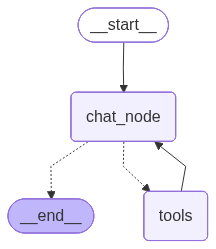

In [9]:
workflow = graph.compile()
workflow

In [10]:
# Chat requiring tool
out = workflow.invoke({"messages": [HumanMessage(content="what is product od 2 and 500")]})
print(out["messages"][-1].content)

BadRequestError: (Request ID: Root=1-698f84d2-6f67f4bb5b22bd172ccc433e;675f0b62-6338-4e98-b847-96b89d141e22)

Bad request: